# Prerequisites:
This notebook assumes that you already know what Principal Component Analysis (PCA) is and why it is useful.

# Scope of this notebook:
This notebook aims at explaining how we can use SVD for PCA.

# Required Packages:
- NumPy: For arrays and dataset generation.
- Matplotlib: For visualisation.
- Jupyterlab: For running Jupyter Notebooks.

All these packages are mentioned in `requirements.txt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

# Principal Component Analysis using SVD:
PCA is a dimensionality reduction technique; it is widely used to project high dimensional data into low dimensions, so that we can visualise it, make model training for machine learning efficient.

To find principal components, we need to find eigenvectors of covariance matrix of our dataset matrix. Suppose dataset matrix is $A$ of shape $m\times n$, $m$ are the number of samples and $n$ is the number of features. Features can be labelled as $F_{1}, F_{2}, F_{3}, \dots, F_{n}$
$$\begin{aligned}
& A=\begin{bmatrix}
a_{11}&a_{12}&\cdots&a_{1n}\\
a_{21}&a_{22}&\cdots&a_{2n}\\
\vdots&\vdots&\ddots&\vdots\\
a_{m1}&a_{m2}&\cdots&a_{mn}
\end{bmatrix}_{(m\times n)}\\
&A=\begin{bmatrix}
a_{1}\\
a_{2}\\
\vdots\\
a_{m}
\end{bmatrix}\qquad\text{Where: }a_{i}=\langle\begin{matrix}a_{i1}&a_{i2}&\cdots&a_{in}\end{matrix}\rangle\\
& \text{Covariance Matrix is represented by: }\Sigma\text{ not to be confused by the diagonal singular matrix.}\\
& \Sigma=\begin{bmatrix}
Cov(f_{1},f_{1})&Cov(f_{1}, f_{2})&\cdots&Cov(f_{1}, f_{n})\\
Cov(f_{2}, f_{1})&Cov(f_{2}, f_{2})&\cdots&Cov(f_{2}, f_{n})\\
\vdots&\vdots&\ddots&\vdots\\
Cov(f_{n}, f_{1})&Cov(f_{n}, f_{2})&\cdots&Cov(f_{n}, f_{n})
\end{bmatrix}_{(n\times n)}\\
& Cov(f_{i}, f_{j})=\frac{\sum_{r=1}^{m}{(f_{i}-\bar{f_{i}})(f_{j}-\bar{f_{j}})}}{m-1}\qquad\text{Where: }f_{i}\text{ are the values for feature }F_{i}\text{ across all samples.}\\
\therefore & \Sigma=\begin{bmatrix}
\frac{\sum_{r=1}^{m}{(f_{1}-\bar{f_{1}})(f_{1}-\bar{f_{1}})}}{m-1}&\frac{\sum_{r=1}^{m}{(f_{1}-\bar{f_{1}})(f_{2}-\bar{f_{2}})}}{m-1}&\cdots&\frac{\sum_{r=1}^{m}{(f_{1}-\bar{f_{1}})(f_{n}-\bar{f_{n}})}}{m-1}\\
\frac{\sum_{r=1}^{m}{(f_{2}-\bar{f_{2}})(f_{1}-\bar{f_{1}})}}{m-1}&\frac{\sum_{r=1}^{m}{(f_{2}-\bar{f_{2}})(f_{2}-\bar{f_{2}})}}{m-1}&\cdots&\frac{\sum_{r=1}^{m}{(f_{2}-\bar{f_{2}})(f_{n}-\bar{f_{n}})}}{m-1}\\
\vdots&\vdots&\ddots&\vdots\\
\frac{\sum_{r=1}^{m}{(f_{n}-\bar{f_{n}})(f_{1}-\bar{f_{1}})}}{m-1}&\frac{\sum_{r=1}^{m}{(f_{n}-\bar{f_{n}})(f_{2}-\bar{f_{2}})}}{m-1}&\cdots&\frac{\sum_{r=1}^{m}{(f_{n}-\bar{f_{n}})(f_{n}-\bar{f_{n}})}}{m-1}
\end{bmatrix}\\
& \text{We center our dataset along its mean and call it }A_{c}\\
& A_{c}=\begin{bmatrix}
(a_{11}-\bar{f_{1}})&(a_{12}-\bar{f_{2}})&\cdots&(a_{1n}-\bar{f_{n}})\\
(a_{21}-\bar{f_{1}})&(a_{22}-\bar{f_{2}})&\cdots&(a_{2n}-\bar{f_{n}})\\
\vdots&\vdots&\ddots&\vdots\\
(a_{m1}-\bar{f_{1}})&(a_{m2}-\bar{f_{2}})&\cdots&(a_{mn}-\bar{f_{n}})
\end{bmatrix}\\
&\Sigma=\frac{1}{m-1}A_{c}^{T}A_{c}\\
&\text{Now we just have to find the eigenvectors of the matrix }\frac{1}{m-1}A_{c}^{T}A_{c}\\
&\text{We know that in SVD of matrix $A$, matrix $V$ is made up of the eigenvectors of the matrix $A^{T}A$}\\
&A=U\Sigma V^{T}\Rightarrow A^{T}A=(U\Sigma V^{T})^{T}(U\Sigma V^{T})=V\Sigma^{T}U^{T}U\Sigma V^{T}\\
&\text{Since matrix $U$ is orthogonal, $U^{T}U=I$.}\\
\therefore& A^{T}A=V\Sigma^{T}\Sigma V^{T}\\
&\frac{A^{T}A}{m-1}=V\frac{\Sigma^{T}\Sigma}{m-1}V^{T}\equiv Q\Lambda Q^{T}\\
&\text{The final equation looks like diagonalization, the matrix $\Lambda$ is a diagonal matrix containing the eigenvalues and matrix $Q$ contains the normalized eigenvectors of the matrix}\\
&\text{Eigenvectors of matrix $\frac{A^{T}A}{m-1}$ are in the matrix $V$ and its eigenvalues are in the matrix $\frac{\Sigma^{T}\Sigma}{m-1}$}\\
&\text{We got matrix $V$ and $\Sigma$ from the decomposition of matrix $A$}\\
&\text{If we decompose matrix $A_{c}$, then we will get matrix $V$ and $\frac{\Sigma^{T}\Sigma}{m-1}$ which contains the eigenvectors and eigenvalues of matrix $\frac{A^{T}A}{m-1}$ (Covariance Matrix) respectively.}\\
\end{aligned}$$

The remaining steps; selecting the desired principal components and projecting the data onto them are identical to the standard PCA procedure. Instead of explicitly constructing the covariance matrix and performing an eigenvalue decomposition, PCA can be computed directly using the SVD of the centered data matrix. This is generally more numerically stable and is especially advantageous when the number of features is large.

# PCA implementation:
To visualise PCA, we need to create our synthetic dataset. For this we will use 2 dimensions and 100 samples.

The dataset would be created using NumPy's `rng` with seed value `42`, also it would be stretch across Y-axis by factor of `SCALE_Y` and X-axis by factor of `SCALE_X`, and then rotated by angle `THETA` degrees from positive X-axis.

In [2]:
SCALE_Y = 5
SCALE_X = 2.5
THETA = np.deg2rad(55)

## Creating Dataset:

In [3]:
rng = np.random.default_rng(seed=42)
X = rng.normal(size=(100, 2))
X[:, 0] *= SCALE_X
X[:, 1] *= SCALE_Y

R = np.array([[np.cos(THETA), -np.sin(THETA)],
              [np.sin(THETA), np.cos(THETA)]])

X = X @ R.T

## Plotting data:
We will make a scatter plot to visualise out synthetic dataset.

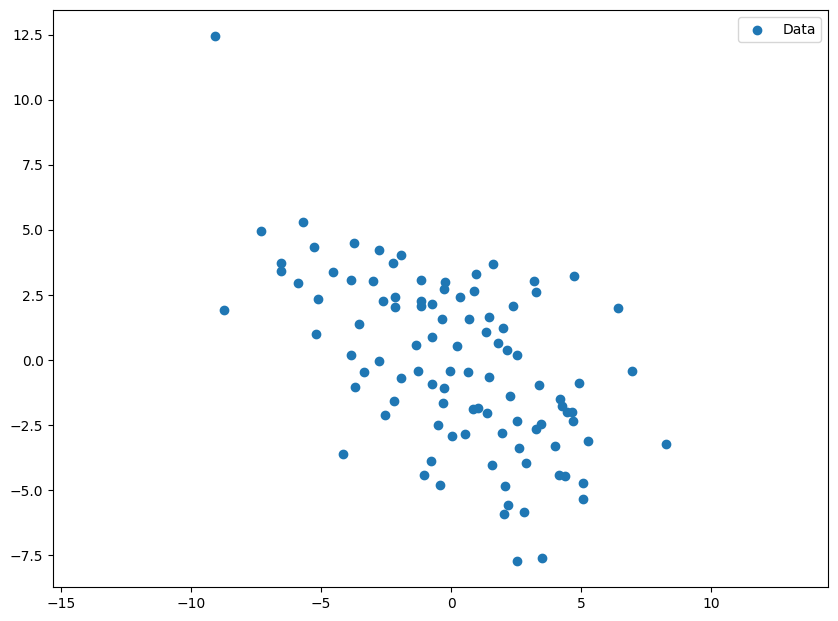

In [4]:
plt.figure(figsize=(10, 7.5))
plt.scatter(X[:, 0], X[:, 1], label="Data")
plt.legend(loc="upper right")
plt.axis("equal")
plt.show()

## Finding principal components:

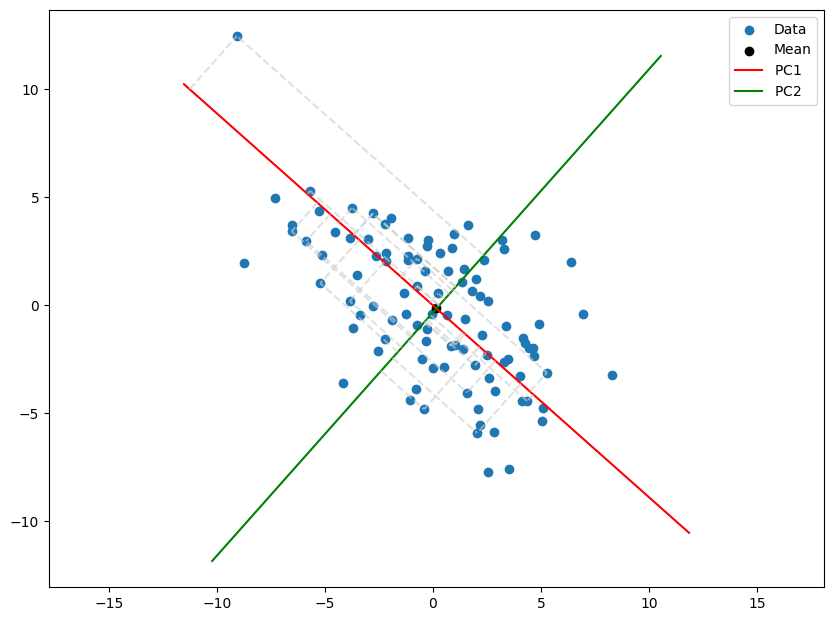

In [5]:
from application.principal_component_analysis import PCA

pca = PCA(n_components=2)
projection = pca.fit_transform(X)
pc1 = pca.V[:, 0]
pc2 = pca.V[:, 1]
mean = pca.mean
pc1_projection = projection[:, 0].reshape(-1, 1) @ pc1.reshape(1, -1) + mean
pc2_projection = projection[:, 1].reshape(-1, 1) @ pc2.reshape(1, -1) + mean

x = np.array([np.min(X[:, 0]), np.max(X[:, 0])])
x_arg = np.array([np.argmin(X[:, 0]), np.argmax(X[:, 0])])
y = np.array([X[x_arg[0], 1], X[x_arg[1], 1]])
distance = np.max(np.linalg.norm(X - mean, axis=1))

p = np.array([[mean-distance*pc1, mean+distance*pc1],
              [mean-distance*pc2, mean+distance*pc2]])

plt.figure(figsize=(10, 7.5))
plt.scatter(X[:, 0], X[:, 1], label="Data")
plt.scatter(mean[0], mean[1], label="Mean", color="black")
plt.plot(p[0, :, 0], p[0, :, 1], label=r"$\text{PC}1$", color="red")
plt.plot(p[1, :, 0], p[1, :, 1], label=r"$\text{PC}2$", color="green")

for i in rng.integers(0, X.shape[0], size=20):
    plt.plot((pc1_projection[i, 0], X[i, 0]), (pc1_projection[i, 1], X[i, 1]), linestyle="--", color="#cacdcd", alpha=0.6)
    plt.plot((pc2_projection[i, 0], X[i, 0]), (pc2_projection[i, 1], X[i, 1]), linestyle="--", color="#cacdcd", alpha=0.6)

plt.legend(loc="upper right")
plt.axis("equal")
plt.show()

## Visualizing the transformations:

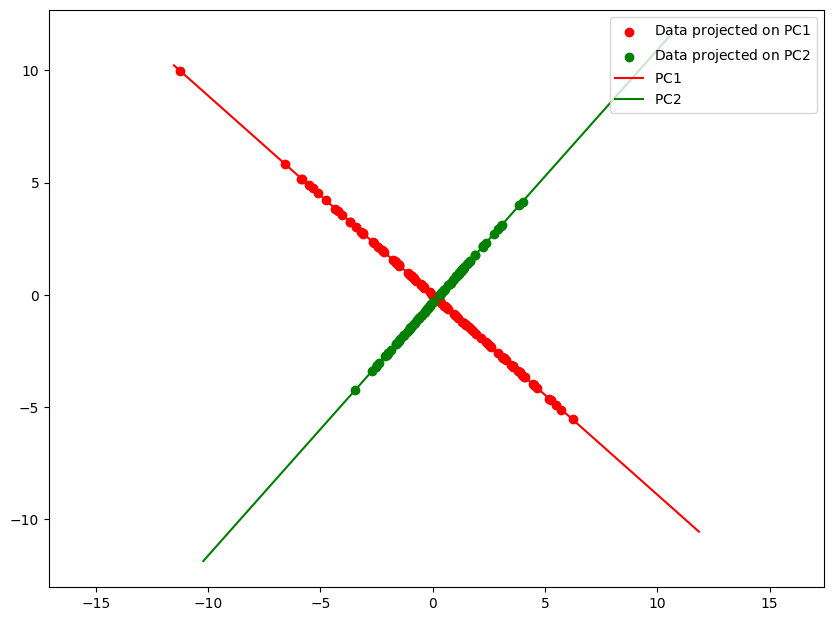

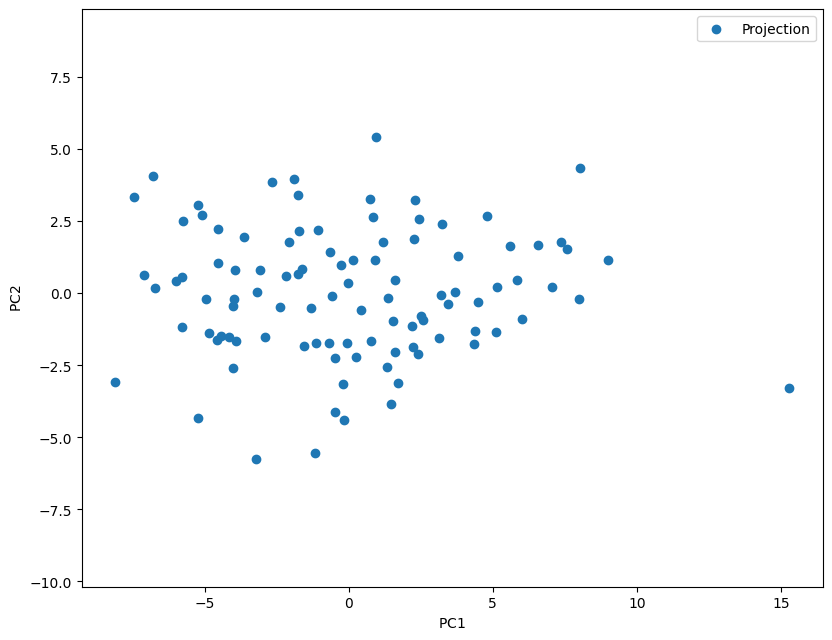

In [6]:
plt.figure(figsize=(10, 7.5))
plt.scatter(pc1_projection[:, 0], pc1_projection[:, 1], label=r"Data projected on $\text{PC}1$", color="red")
plt.scatter(pc2_projection[:, 0], pc2_projection[:, 1], label=r"Data projected on $\text{PC}2$", color="green")
plt.plot(p[0, :, 0], p[0, :, 1], label=r"$\text{PC}1$", color="red")
plt.plot(p[1, :, 0], p[1, :, 1], label=r"$\text{PC}2$", color="green")
plt.legend(loc="upper right")
plt.axis("equal")
plt.show()

plt.figure(figsize=(9.56, 7.5))
plt.scatter(projection[:, 0], projection[:, 1], label="Projection")
plt.xlabel(r"$\text{PC}1$")
plt.ylabel(r"$\text{PC}2$")
plt.legend(loc="upper right")
plt.axis("equal")
plt.show()